# BK Sentinel — Notebook 02: Layer 1 Classification

**Project:** BK Sentinel — Three-Layer Dynamic Credit Risk Transition System  
**Author:** Denyse Mutoni Uwingeneye  
**Institution:** African Leadership University  

---

This notebook covers Layer 1 of BK Sentinel:
1. Load the verified panel dataset from Notebook 01
2. Prepare features and target variable
3. Train Logistic Regression (baseline)
4. Train Random Forest
5. Train XGBoost
6. Compare all three models
7. SHAP explainability on the best model
8. Save the best model

**Target:** Predict `next_risk_state` (Low, Medium, High, Default) from current month features  
**Evaluation:** Macro F1 score and recall for High and Default classes

## 0. Import libraries

In [27]:
import sys
!{sys.executable} -m pip install imbalanced-learn shap

/Users/df-9/.zshenv:export:1: not valid in this context: Support/JetBrains/Toolbox/scripts://Users/df-9/development/flutter/bin:/Users/df-9/.rvm/bin:/Users/df-9/fvm/default/bin

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE

import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries imported successfully.')

All libraries imported successfully.


## 1. Load the verified dataset

In [29]:
df = pd.read_csv('bk_sentinel_verified.csv', low_memory=False)

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Months: {sorted(df["observation_month"].unique())}')

Dataset loaded: 67,904 rows x 26 columns
Months: ['2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']


## 2. Feature selection and target preparation

In [30]:
# Features for Layer 1
# These are the columns available at month t to predict the state at month t+1
NUMERIC_FEATURES = [
    'days_in_arrears',
    'instalments_in_arrears',
    'principal_balance',
    'principal_due',
    'penal_interest',
    'suspended_interest',
    'interest_due',
    'accrued_interest',
    'all_crb',
    'interest_rate',
    'loan_term_months',
    'number_instalments_paid',
    'disbursed_amount_lcy',
    'repayment_ratio',
    'loan_age_months',
    'arrears_ratio',
]

CATEGORICAL_FEATURES = [
    'segment',
    'loan_type',
]

TARGET = 'next_risk_state'

# Keep only rows where we have a valid next_risk_state (not the last month)
df_ml = df.dropna(subset=[TARGET]).copy()
print(f'Records with valid target: {len(df_ml):,}')
print(f'Records dropped (last month per loan): {len(df) - len(df_ml):,}')

print(f'\nTarget distribution:')
print(df_ml[TARGET].value_counts())

Records with valid target: 63,660
Records dropped (last month per loan): 4,244

Target distribution:
next_risk_state
Low        36179
Default    13564
Medium      9347
High        4570
Name: count, dtype: int64


In [31]:
# Encode categorical features
df_encoded = df_ml.copy()

le_segment = LabelEncoder()
le_loan_type = LabelEncoder()

df_encoded['segment_enc'] = le_segment.fit_transform(df_encoded['segment'].astype(str))
df_encoded['loan_type_enc'] = le_loan_type.fit_transform(df_encoded['loan_type'].astype(str))

# Encode target
risk_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Default': 3}
risk_labels = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Default'}
df_encoded['target_code'] = df_encoded[TARGET].map(risk_map)

# Build feature matrix
FEATURE_COLS = NUMERIC_FEATURES + ['segment_enc', 'loan_type_enc']

# Fill any remaining nulls in features with 0
df_encoded[FEATURE_COLS] = df_encoded[FEATURE_COLS].fillna(0)

X = df_encoded[FEATURE_COLS].values
y = df_encoded['target_code'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Feature columns: {FEATURE_COLS}')

Feature matrix shape: (63660, 18)
Feature columns: ['days_in_arrears', 'instalments_in_arrears', 'principal_balance', 'principal_due', 'penal_interest', 'suspended_interest', 'interest_due', 'accrued_interest', 'all_crb', 'interest_rate', 'loan_term_months', 'number_instalments_paid', 'disbursed_amount_lcy', 'repayment_ratio', 'loan_age_months', 'arrears_ratio', 'segment_enc', 'loan_type_enc']


## 3. Train-test split (time-based — no data leakage)

In [32]:
# Time-based split: train on months 1-13, test on months 14-15
# This prevents data leakage — the model never sees future data during training

months = sorted(df_encoded['observation_month'].unique())
train_months = months[:-2]  # first 14 months
test_months = months[-2:]   # last 2 months

print(f'Training months: {train_months}')
print(f'Test months:     {test_months}')

train_idx = df_encoded['observation_month'].isin(train_months)
test_idx = df_encoded['observation_month'].isin(test_months)

X_train = df_encoded.loc[train_idx, FEATURE_COLS].fillna(0).values
X_test  = df_encoded.loc[test_idx,  FEATURE_COLS].fillna(0).values
y_train = df_encoded.loc[train_idx, 'target_code'].values
y_test  = df_encoded.loc[test_idx,  'target_code'].values

print(f'\nTraining set: {X_train.shape[0]:,} records')
print(f'Test set:     {X_test.shape[0]:,} records')
print(f'\nTraining target distribution:')
for code, label in risk_labels.items():
    count = (y_train == code).sum()
    print(f'  {label}: {count:,} ({count/len(y_train)*100:.1f}%)')

Training months: ['2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10']
Test months:     ['2025-11', '2025-12']

Training set: 55,172 records
Test set:     8,488 records

Training target distribution:
  Low: 32,023 (58.0%)
  Medium: 8,148 (14.8%)
  High: 3,914 (7.1%)
  Default: 11,087 (20.1%)


## 4. Apply SMOTE to handle class imbalance

In [33]:
# SMOTE generates synthetic minority class examples
# Applied only to training data — never to test data

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE — training distribution:')
for code, label in risk_labels.items():
    count = (y_train_sm == code).sum()
    print(f'  {label}: {count:,} ({count/len(y_train_sm)*100:.1f}%)')
print(f'\nTotal training records after SMOTE: {len(X_train_sm):,}')

After SMOTE — training distribution:
  Low: 32,023 (25.0%)
  Medium: 32,023 (25.0%)
  High: 32,023 (25.0%)
  Default: 32,023 (25.0%)

Total training records after SMOTE: 128,092


## 5. Model 1 — Logistic Regression (Baseline)

In [34]:
print('Training Logistic Regression...')

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)

lr_f1     = f1_score(y_test, y_pred_lr, average='macro')
lr_recall_high    = recall_score(y_test, y_pred_lr, labels=[2], average='macro')
lr_recall_default = recall_score(y_test, y_pred_lr, labels=[3], average='macro')

print(f'\nLogistic Regression Results:')
print(f'  Macro F1 Score:      {lr_f1:.4f}')
print(f'  Recall (High):       {lr_recall_high:.4f}')
print(f'  Recall (Default):    {lr_recall_default:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr,
      target_names=['Low','Medium','High','Default']))

Training Logistic Regression...

Logistic Regression Results:
  Macro F1 Score:      0.5952
  Recall (High):       0.6951
  Recall (Default):    0.9411

Classification Report:
              precision    recall  f1-score   support

         Low       0.77      0.25      0.38      4156
      Medium       0.22      0.74      0.34      1199
        High       0.72      0.70      0.71       656
     Default       0.98      0.94      0.96      2477

    accuracy                           0.56      8488
   macro avg       0.67      0.66      0.60      8488
weighted avg       0.75      0.56      0.57      8488



## 6. Model 2 — Random Forest

In [35]:
print('Training Random Forest...')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

rf_f1     = f1_score(y_test, y_pred_rf, average='macro')
rf_recall_high    = recall_score(y_test, y_pred_rf, labels=[2], average='macro')
rf_recall_default = recall_score(y_test, y_pred_rf, labels=[3], average='macro')

print(f'\nRandom Forest Results:')
print(f'  Macro F1 Score:      {rf_f1:.4f}')
print(f'  Recall (High):       {rf_recall_high:.4f}')
print(f'  Recall (Default):    {rf_recall_default:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf,
      target_names=['Low','Medium','High','Default']))

Training Random Forest...

Random Forest Results:
  Macro F1 Score:      0.8210
  Recall (High):       0.6890
  Recall (Default):    0.9520

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      0.92      0.93      4156
      Medium       0.65      0.74      0.70      1199
        High       0.71      0.69      0.70       656
     Default       0.97      0.95      0.96      2477

    accuracy                           0.88      8488
   macro avg       0.82      0.83      0.82      8488
weighted avg       0.89      0.88      0.89      8488



## 7. Model 3 — XGBoost

In [36]:
print('Training XGBoost...')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)

xgb_f1     = f1_score(y_test, y_pred_xgb, average='macro')
xgb_recall_high    = recall_score(y_test, y_pred_xgb, labels=[2], average='macro')
xgb_recall_default = recall_score(y_test, y_pred_xgb, labels=[3], average='macro')

print(f'\nXGBoost Results:')
print(f'  Macro F1 Score:      {xgb_f1:.4f}')
print(f'  Recall (High):       {xgb_recall_high:.4f}')
print(f'  Recall (Default):    {xgb_recall_default:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_xgb,
      target_names=['Low','Medium','High','Default']))

Training XGBoost...

XGBoost Results:
  Macro F1 Score:      0.8246
  Recall (High):       0.6860
  Recall (Default):    0.9576

Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.94      0.94      4156
      Medium       0.71      0.70      0.70      1199
        High       0.71      0.69      0.70       656
     Default       0.97      0.96      0.96      2477

    accuracy                           0.89      8488
   macro avg       0.83      0.82      0.82      8488
weighted avg       0.89      0.89      0.89      8488



## 8. Model comparison

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Macro F1': [lr_f1, rf_f1, xgb_f1],
    'Recall High': [lr_recall_high, rf_recall_high, xgb_recall_high],
    'Recall Default': [lr_recall_default, rf_recall_default, xgb_recall_default],
})

print('='*60)
print('MODEL COMPARISON SUMMARY')
print('='*60)
print(results.to_string(index=False))

# Select best model based on Macro F1
best_idx = results['Macro F1'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f'\nBest model: {best_model_name} (Macro F1 = {results.loc[best_idx, "Macro F1"]:.4f})')

# Assign best model
if best_idx == 0:
    best_model = lr
    y_pred_best = y_pred_lr
elif best_idx == 1:
    best_model = rf
    y_pred_best = y_pred_rf
else:
    best_model = xgb
    y_pred_best = y_pred_xgb

MODEL COMPARISON SUMMARY
              Model  Macro F1  Recall High  Recall Default
Logistic Regression    0.5952       0.6951          0.9411
      Random Forest    0.8210       0.6890          0.9520
            XGBoost    0.8246       0.6860          0.9576

Best model: XGBoost (Macro F1 = 0.8246)


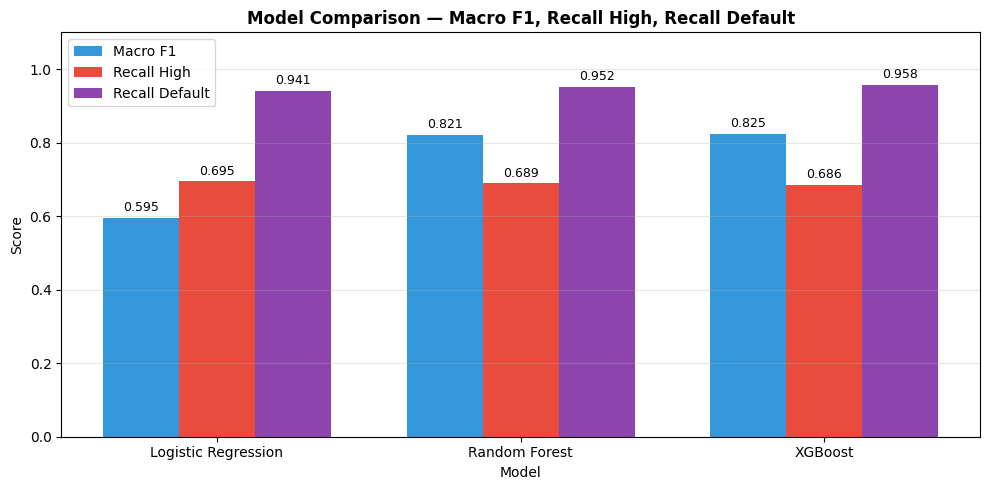

In [38]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.25

bars1 = ax.bar(x - width, results['Macro F1'], width, label='Macro F1', color='#3498db')
bars2 = ax.bar(x, results['Recall High'], width, label='Recall High', color='#e74c3c')
bars3 = ax.bar(x + width, results['Recall Default'], width, label='Recall Default', color='#8e44ad')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Macro F1, Recall High, Recall Default', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

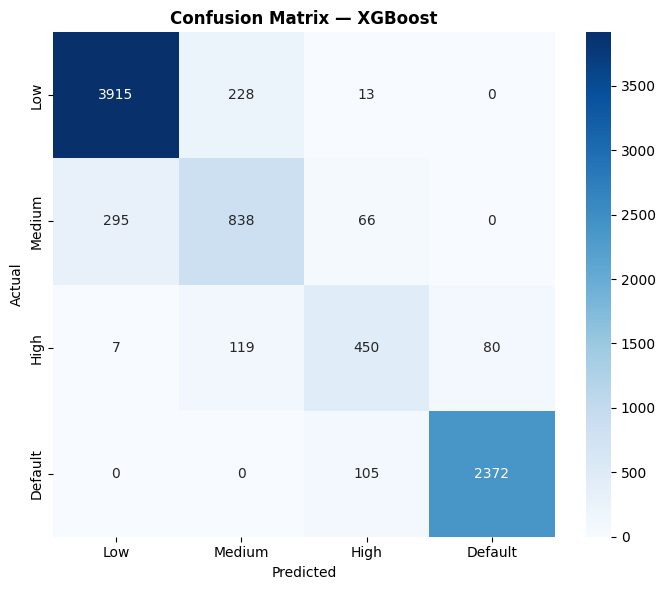

In [39]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=['Low','Medium','High','Default'],
    yticklabels=['Low','Medium','High','Default'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SHAP Explainability on best model

In [40]:
print(f'Computing SHAP values for {best_model_name}...')
print('This may take a minute.')

# Use a sample for SHAP computation (faster)
shap_sample_size = min(1000, len(X_test))
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), shap_sample_size, replace=False)
X_shap = X_test[shap_idx]

if best_idx == 2:  # XGBoost
    explainer = shap.TreeExplainer(best_model)
elif best_idx == 1:  # Random Forest
    explainer = shap.TreeExplainer(best_model)
else:  # Logistic Regression
    explainer = shap.LinearExplainer(best_model, X_train_sm)

shap_values = explainer.shap_values(X_shap)
print('SHAP values computed.')

Computing SHAP values for XGBoost...
This may take a minute.
SHAP values computed.


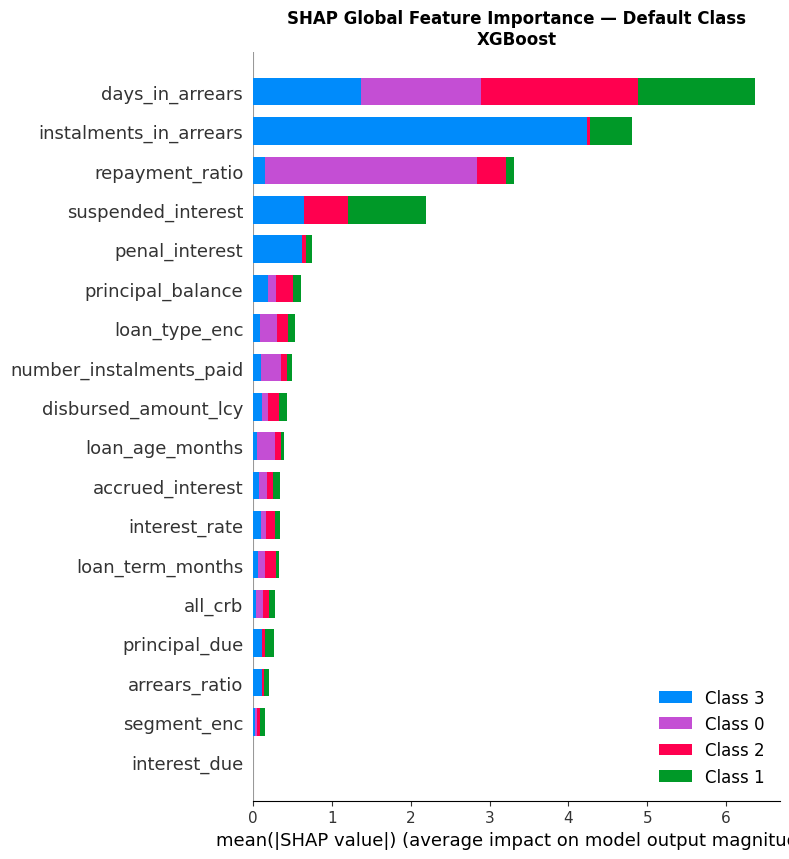

SHAP global chart saved.


In [41]:
# Global SHAP — summary plot for Default class (class index 3)
# This shows which features most strongly push accounts toward Default

feature_names = FEATURE_COLS

plt.figure(figsize=(10, 7))
if isinstance(shap_values, list):
    # Multi-class — show Default class (index 3)
    shap.summary_plot(
        shap_values[3], X_shap,
        feature_names=feature_names,
        plot_type='bar',
        show=False
    )
else:
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=feature_names,
        plot_type='bar',
        show=False
    )

plt.title(f'SHAP Global Feature Importance — Default Class\n{best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('02_shap_global_default.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP global chart saved.')

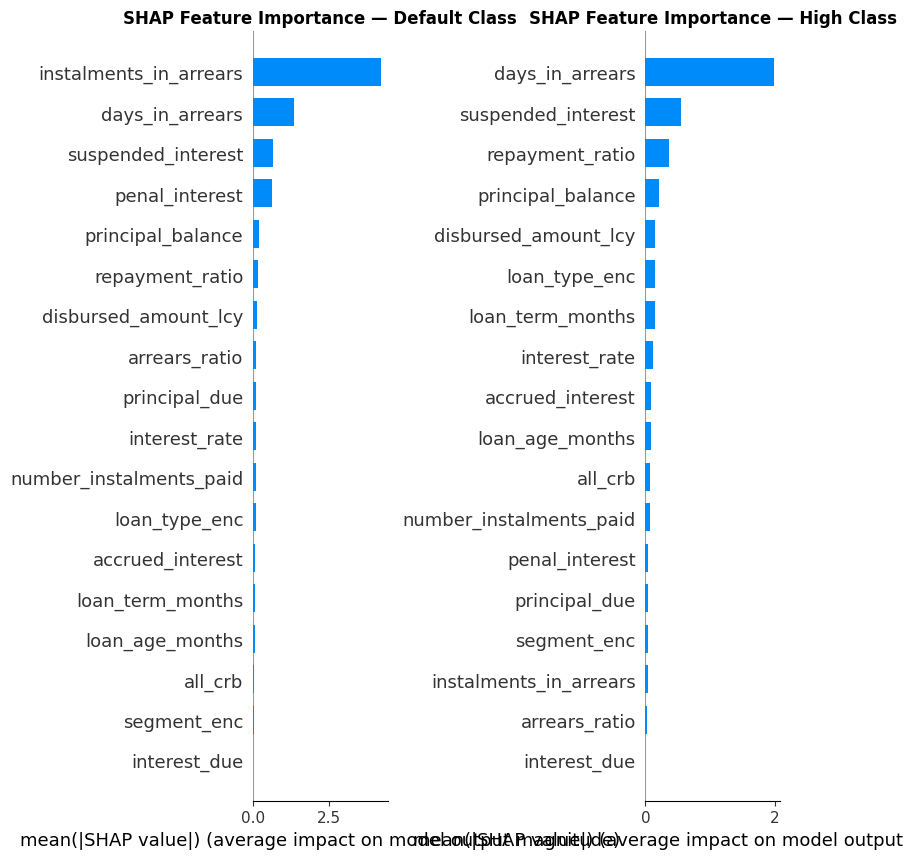

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_values[3] if isinstance(shap_values, list) else np.array(shap_values)[:, :, 3],
    X_shap, feature_names=feature_names,
    plot_type='bar', show=False
)
axes[0].set_title('SHAP Feature Importance — Default Class', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(
    shap_values[2] if isinstance(shap_values, list) else np.array(shap_values)[:, :, 2],
    X_shap, feature_names=feature_names,
    plot_type='bar', show=False
)
axes[1].set_title('SHAP Feature Importance — High Class', fontweight='bold')

plt.tight_layout()
plt.savefig('02_shap_global_both.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x700 with 0 Axes>

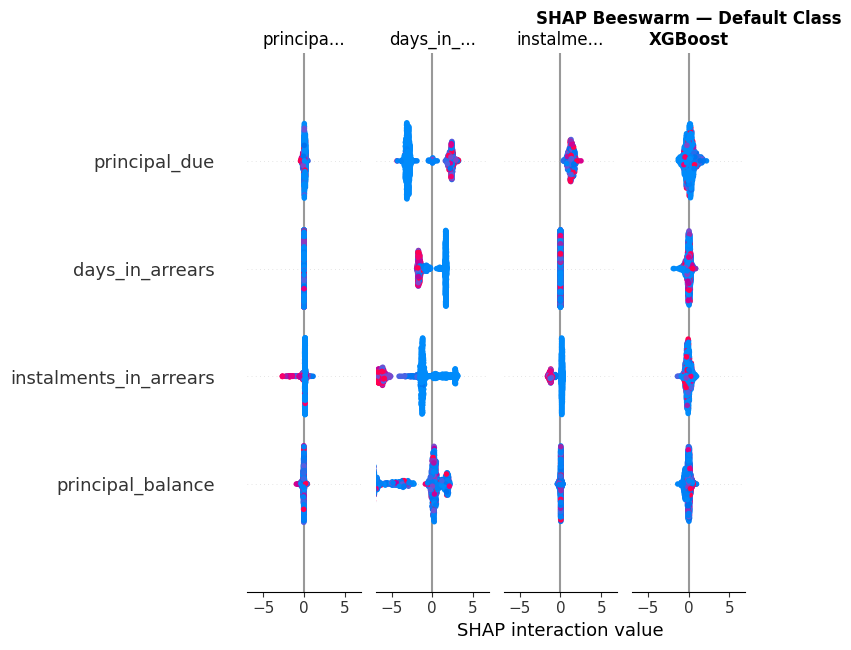

In [43]:
# SHAP beeswarm plot — shows direction and magnitude of each feature

plt.figure(figsize=(10, 7))
if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[3], X_shap,
        feature_names=feature_names,
        show=False
    )
else:
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=feature_names,
        show=False
    )

plt.title(f'SHAP Beeswarm — Default Class\n{best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('02_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining prediction for sample account at index 2:
Actual state:    Default
Predicted state: Default


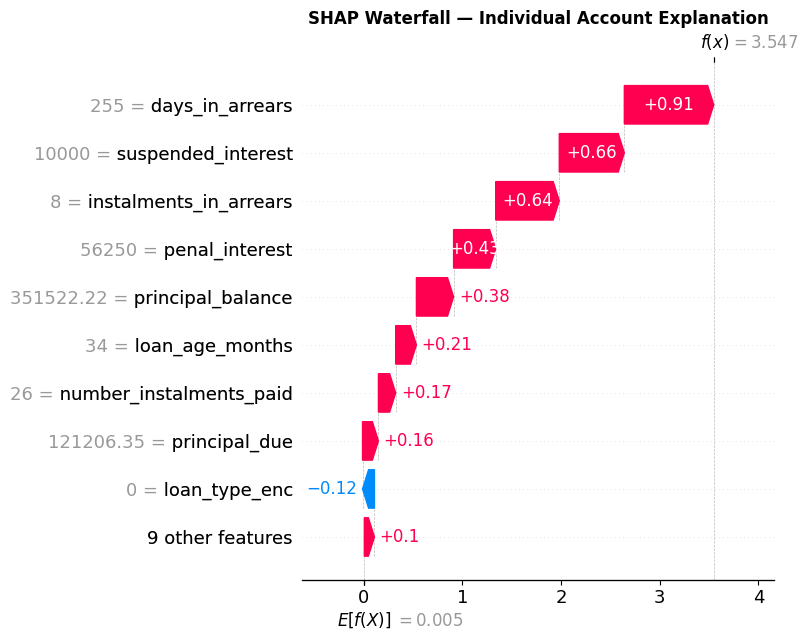

Waterfall chart saved.


In [44]:
default_indices = np.where(y_pred_best[shap_idx] == 3)[0]

if len(default_indices) > 0:
    sample_idx = default_indices[0]
    print(f'Explaining prediction for sample account at index {sample_idx}:')
    print(f'Actual state:    {risk_labels[y_test[shap_idx[sample_idx]]]}')
    print(f'Predicted state: {risk_labels[y_pred_best[shap_idx[sample_idx]]]}')

    # Handle both SHAP output formats
    if isinstance(shap_values, list):
        # Old format — list of arrays, one per class
        sv = shap_values[3][sample_idx]
        ev = float(explainer.expected_value[3])
    elif len(np.array(shap_values).shape) == 3:
        # New format — 3D array (samples, features, classes)
        sv = np.array(shap_values)[sample_idx, :, 3]
        ev = float(explainer.expected_value[3])
    else:
        sv = shap_values[sample_idx]
        ev = float(explainer.expected_value)

    explanation = shap.Explanation(
        values=sv,
        base_values=ev,
        data=X_shap[sample_idx],
        feature_names=feature_names
    )
    shap.plots.waterfall(explanation, show=False)
    plt.title('SHAP Waterfall — Individual Account Explanation', fontweight='bold')
    plt.tight_layout()
    plt.savefig('02_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Waterfall chart saved.')

## 10. Save the best model

In [45]:
# Save best model, feature list, and encoders
with open('bk_best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('bk_label_encoders.pkl', 'wb') as f:
    pickle.dump({'segment': le_segment, 'loan_type': le_loan_type}, f)

# Save feature names for Layer 3 and dashboard
import json
with open('bk_feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print(f'Best model saved: bk_best_model.pkl ({best_model_name})')
print('Label encoders saved: bk_label_encoders.pkl')
print('Feature list saved: bk_feature_cols.json')

Best model saved: bk_best_model.pkl (XGBoost)
Label encoders saved: bk_label_encoders.pkl
Feature list saved: bk_feature_cols.json


## 11. Summary

In [46]:
print('='*60)
print('NOTEBOOK 02 COMPLETE — LAYER 1 SUMMARY')
print('='*60)
print(f'Best model:          {best_model_name}')
print(f'Macro F1 score:      {results.loc[best_idx, "Macro F1"]:.4f}')
print(f'Recall (High):       {results.loc[best_idx, "Recall High"]:.4f}')
print(f'Recall (Default):    {results.loc[best_idx, "Recall Default"]:.4f}')
print()
print('Files saved:')
print('  bk_best_model.pkl        — champion model for dashboard')
print('  bk_label_encoders.pkl    — segment and loan_type encoders')
print('  bk_feature_cols.json     — feature list')
print()
print('Charts saved:')
print('  02_model_comparison.png')
print('  02_confusion_matrix.png')
print('  02_shap_global_default.png')
print('  02_shap_beeswarm.png')
print('  02_shap_waterfall.png')

NOTEBOOK 02 COMPLETE — LAYER 1 SUMMARY
Best model:          XGBoost
Macro F1 score:      0.8246
Recall (High):       0.6860
Recall (Default):    0.9576

Files saved:
  bk_best_model.pkl        — champion model for dashboard
  bk_label_encoders.pkl    — segment and loan_type encoders
  bk_feature_cols.json     — feature list

Charts saved:
  02_model_comparison.png
  02_confusion_matrix.png
  02_shap_global_default.png
  02_shap_beeswarm.png
  02_shap_waterfall.png


In [47]:
import pandas as pd
import numpy as np
import pickle
import json

# Load saved model artifacts
with open('bk_best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)
with open('bk_label_encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
with open('bk_feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

# Load the three individual models — check what they are named in your notebook
# Run this to find the names:
print('feature_cols:', feature_cols[:3])
print('encoders keys:', list(encoders.keys()))

feature_cols: ['days_in_arrears', 'instalments_in_arrears', 'principal_balance']
encoders keys: ['segment', 'loan_type']


In [48]:
# Find your model variable names
for name in ['lr', 'rf', 'xgb', 'log_reg', 'rf_model', 'xgb_model', 
             'best_model', 'models', 'logistic', 'random_forest']:
    try:
        val = eval(name)
        print(f'{name} exists: {type(val)}')
    except:
        pass

lr exists: <class 'sklearn.linear_model._logistic.LogisticRegression'>
rf exists: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
xgb exists: <class 'xgboost.sklearn.XGBClassifier'>
best_model exists: <class 'xgboost.sklearn.XGBClassifier'>


In [49]:
import pandas as pd
import numpy as np
import pickle
import json

# Load saved artifacts
with open('bk_label_encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
with open('bk_feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

rl = {0:'Low', 1:'Medium', 2:'High', 3:'Default'}

# Load full dataset
df_full = pd.read_csv('bk_sentinel_verified.csv', low_memory=False)
df_full['segment_enc']   = encoders['segment'].transform(df_full['segment'].astype(str).fillna('UNKNOWN'))
df_full['loan_type_enc'] = encoders['loan_type'].transform(df_full['loan_type'].astype(str).fillna('UNKNOWN'))
for c in feature_cols:
    if c not in df_full.columns: df_full[c] = 0
df_full[feature_cols] = df_full[feature_cols].fillna(0)
X_full = df_full[feature_cols].values

# Use the individual model variables from your notebook
models_compare = {
    'logistic_regression': lr,
    'random_forest':       rf,
    'xgboost':             xgb,
}

for model_name, model in models_compare.items():
    preds = model.predict(X_full)
    proba = model.predict_proba(X_full)
    df_full[f'pred_{model_name}']      = [rl[p] for p in preds]
    df_full[f'p_default_{model_name}'] = proba[:, 3]
    df_full[f'p_high_{model_name}']    = proba[:, 2]

df_full.to_csv('bk_sentinel_model_comparison.csv', index=False)
print('Saved: bk_sentinel_model_comparison.csv')

for model_name in models_compare:
    total = len(df_full)
    counts = df_full[f'pred_{model_name}'].value_counts()
    print(f'\n{model_name.replace("_"," ").title()} prediction distribution:')
    print(f'  {"State":<12} {"Count":>8} {"Percentage":>12}')
    print(f'  {"-"*34}')
    for state in ['Low', 'Medium', 'High', 'Default']:
        n   = counts.get(state, 0)
        pct = n / total * 100
        print(f'  {state:<12} {n:>8,} {pct:>11.1f}%')
    print(f'  {"-"*34}')
    print(f'  {"Total":<12} {total:>8,} {"100.0%":>12}')

Saved: bk_sentinel_model_comparison.csv

Logistic Regression prediction distribution:
  State           Count   Percentage
  ----------------------------------
  Low            34,907        51.4%
  Medium         14,047        20.7%
  High            4,988         7.3%
  Default        13,962        20.6%
  ----------------------------------
  Total          67,904       100.0%

Random Forest prediction distribution:
  State           Count   Percentage
  ----------------------------------
  Low            37,975        55.9%
  Medium         10,551        15.5%
  High            4,900         7.2%
  Default        14,478        21.3%
  ----------------------------------
  Total          67,904       100.0%

Xgboost prediction distribution:
  State           Count   Percentage
  ----------------------------------
  Low            39,100        57.6%
  Medium          9,396        13.8%
  High            4,822         7.1%
  Default        14,586        21.5%
  ------------------------